----------------------------------------------------------------------------------------------------

# ***Cookies e Headers - FastAPI***

----------------------------------------------------------------------------------------------------

- Cookie - https://fastapi.tiangolo.com/tutorial/cookie-params/
- Header - https://fastapi.tiangolo.com/tutorial/header-params/

----------------------------------------------------------------------------------------------------

## ***1. Cookies*** 

Cookies são pequenos arquivos de texto (até 4KB) que servidores enviam ao navegador para armazenar dados do usuário localmente. Eles permitem "lembrar" preferências, sessões de login ou carrinho de compras em sites, já que HTTP é sem estado (cada requisição é independente).

----------------------------------------------------------------------------------------------------

### ***1.1. Como Funcionam***

O servidor envia: 
- Set-Cookie: nome=valor; 
- Expires=... na resposta HTTP. 

O navegador salva e reenviará Cookie: 
- nome=valor em próximas requisições ao mesmo domínio.

----------------------------------------------------------------------------------------------------

### ***1.2. Tipos de Cookies***

| Tipo        | Descrição                  | Exemplo                            |
| ----------- | -------------------------- | ---------------------------------- |
| Session     | Expira ao fechar navegador | Login temporário brightdata        |
| Persistent  | Data de expiração fixa     | "Lembrar-me"                       |
| Secure      | Só HTTPS                   | Pagamentos                         |
| HttpOnly    | Invisível a JS (anti-XSS)  | Tokens sensíveis developer.mozilla |
| Third-party | De domínio diferente       | Anúncios (rastreamento)            |

----------------------------------------------------------------------------------------------------

### ***1.3. Tipos de Cookies***

- Riscos: Sequestro de sessão (roubo de cookie via XSS ou MITM). Use Secure + HttpOnly + SameSite=Strict.

- LGPD: Consentimento obrigatório para cookies não essenciais (marketing). No Brasil, banners "Aceitar cookies" são comuns.

- Bloqueio: Navegadores como Chrome permitem limpar/bloquear (Configurações > Privacidade).

----------------------------------------------------------------------------------------------------

## ***2. Implementando o parâmetros de Cookies*** 

Adicionaremos e atualizaremos o nosso código da seguinte maneira:

In [ ]:
from fastapi import Cookie, FastAPI, status
from typing import Annotated

No corpo do código, a implementação ocorrerá no READ do nosso código:

In [ ]:
# implementando cookies
@app.get('/posts/')
def read_posts(published: bool, limit: int, skip: int = 0, ads_id: Annotated[str | None, Cookie()] = None):
    print(f"Cookie: ads_id")
    
    posts = []
    for post in fake_db:
        if len(posts) == limit:
            break
        
        if post["published"] is published:
            posts.append(post)

    return posts

### ***2.1. Realizando testes***

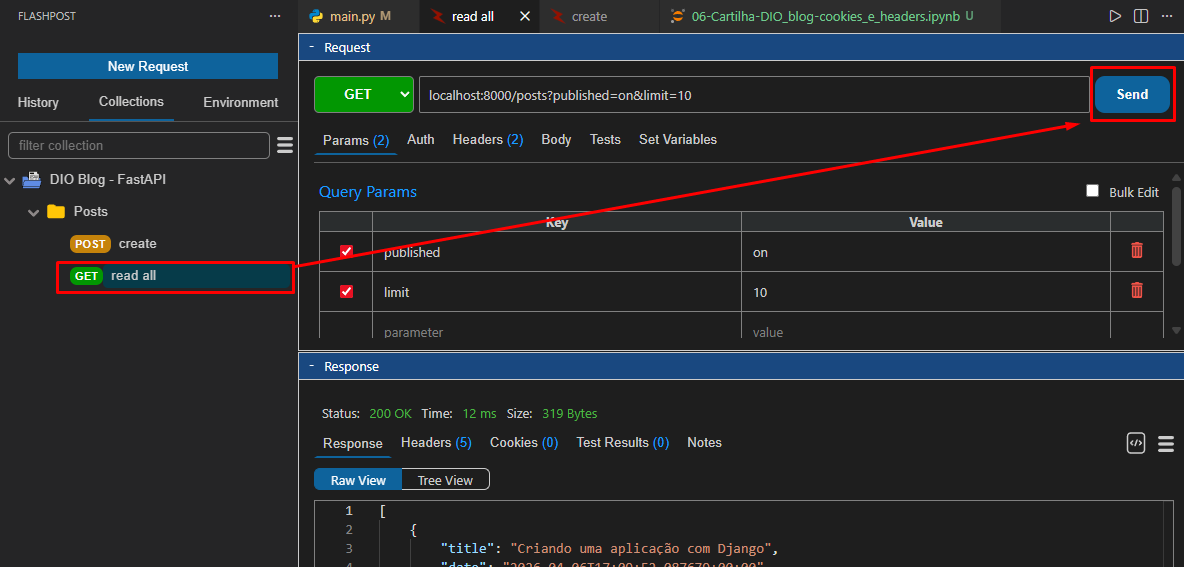

Ao enviarmos o 'Send', em 'read all', é possível perceber uma alteração no Terminal:

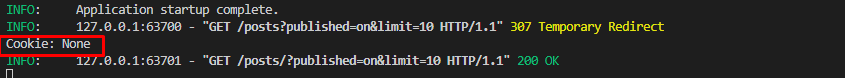

Como resolver isso:

### ***2.2. Corrigindo o 'None' dos Cookies***

No seu 'FastPost', e com o 'FastClient' também instalado, siga o seguinte caminho:

Vamos criar um arquivo .http ou .rest:

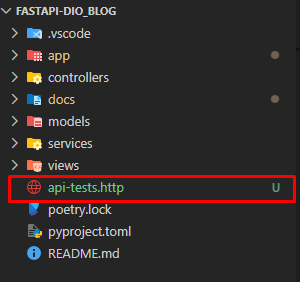

Ao acessa-lo, iremos criar um Cookie e definir alguns pontos:

In [ ]:
###
GET http://127.0.0.1:8000/posts/?published=true&limit=10
Cookie: ads_id=teste123

Nota: É importante que exista os três # acima do GET para que a opção 'Send Request' apareça. 

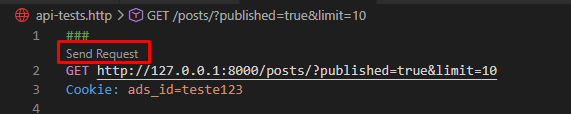

Em seguida, clicamos em 'Send Request'.

Resultado esperado no terminal:

Cookie: 'teste123'
INFO:     127.0.0.1:53071 - "GET /posts/?published=true&limit=10 HTTP/1.1" 200 OK

----------------------------------------------------------------------------------------------------

## ***3. Leitura de um Cookies*** 

Adicionaremos a classe 'Response' para o nosso código

In [ ]:
from fastapi import Response, Cookie, FastAPI, status

Faremos uma pequena mudança no 'Read' do nosso código:

In [ ]:
@app.get('/posts/')
def read_posts(response: Response, published: bool, limit: int, skip: int = 0, ads_id: Annotated[str | None, Cookie()] = None):
    # lendo um cookie (é o que geralmente mais fazemos):
    response.set_cookie(key= 'user_felipe', value= 'felipe.arq@inlook.com')

    # definindo um cookie:
    print(f"Cookie: '{ads_id}'")

    filtered = [p for p in fake_db if p["published"] == published]
    posts = filtered[skip: skip + limit]  

    return posts

Se voltarmos ao RestPost, e em 'read all' e então 'Send', perceba que haverá uma atualização na área de 'Cookies':

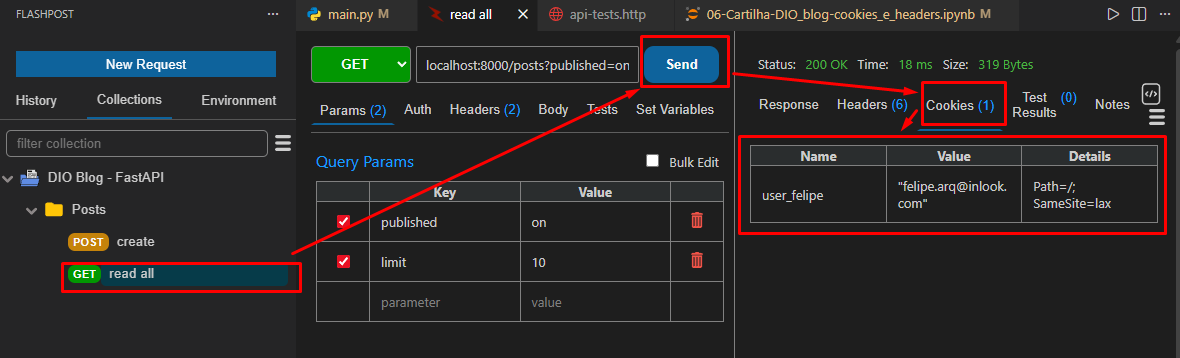

Correto. Ocorreu a leitura corretamente

----------------------------------------------------------------------------------------------------

## ***4. A diferença entre Cookies e Sessões*** 

Cookies e sessões mantêm estado em apps web (HTTP é "sem memória"), mas diferem em local de armazenamento e segurança. Cookies ficam no navegador (cliente), sessões no servidor.

Cookies e sessões mantêm estado em apps web (HTTP é "sem memória"), mas diferem em local de armazenamento e segurança. Cookies ficam no navegador (cliente), sessões no servidor.

### ***4.1. Comparação***

| Aspecto       | Cookies                                | Sessões                                             |
| ------------- | -------------------------------------- | --------------------------------------------------- |
| Armazenamento | Navegador (arquivo texto) brightdata   | Servidor (memória/arquivo/DB) klauslaube            |
| Tamanho       | Pequeno (~4KB por cookie)              | Maior (limitado por servidor)                       |
| Conteúdo      | Dados simples (ID sessão, prefs)       | Dados sensíveis (usuário logado) gitbook.ganeshicmc |
| Segurança     | Visível/editable (use HttpOnly/Secure) | Seguro (só ID no cookie) stackoverflow              |
| Persistência  | Pode durar meses/anos                  | Expira ao fechar browser ou timeout                 |
| Exemplo       | Carrinho no e-commerce                 | Login ativo                                         |

### ***4.2. Como Sessões Usam Cookies***

Sessão: Servidor gera ID único → Envia como cookie (`Set-Cookie: session_id=abc123`) → Cliente reenviar → Servidor busca dados pelo ID.

No FastAPI: Use `request.cookies['session_id']` ou `SessionMiddleware`. 

### ***4.3. Quando Usar***

- Cookies: Preferências ("tema escuro"), tracking.

- Sessões: Autenticação (mais seguras para dados privados).

Seu blog pode usar sessão para "usuário logado" via cookie ID – combina ambos!

----------------------------------------------------------------------------------------------------

# ***Headers***

----------------------------------------------------------------------------------------------------

Headers HTTP são metadados (pares chave-valor) enviados no início de requisições/respostas para controlar comunicação, autenticação e conteúdo. Eles não fazem parte do body, mas definem "como" processar dados.

## ***1. Como Funcionam*** 

Cliente envia headers na requisição (ex.: `User-Agent: Chrome`), servidor responde com headers (ex.: `Content-Type: application/json`). São case-insensitive.

Exemplo: Seu FastAPI lê `ads_id` cookie (header Cookie).

## ***2. Tipos Comuns*** 

| Header        | Uso               | Exemplo                       |
| ------------- | ----------------- | ----------------------------- |
| Content-Type  | Tipo de dado      | application/json h2it.com     |
| Authorization | Autenticação      | Bearer token123               |
| User-Agent    | Info do cliente   | Mozilla/5.0 (Windows)         |
| Cookie        | Dados armazenados | ads_id=teste                  |
| Accept        | Formatos aceitos  | application/json devmedia.com |

## ***3. Em FastAPI*** 

In [ ]:
from fastapi import Header, HTTPException

@app.get("/posts/")
async def read_posts(x_token: str = Header()):
    if x_token != "secret":
        raise HTTPException(401)
    return fake_db

## ***4. Aplicando no código o Header*** 

### ***4.1. Aletração do código:***

In [ ]:
@app.get('/posts/')
def read_posts(
    response: Response, 
    published: bool, 
    limit: int, 
    skip: int = 0, 
    ads_id: Annotated[str | None, Cookie()] = None,
    # implementando o header 
    user_agent: Annotated[str | None, Header()] = None
    
    ):

    response.set_cookie(key= 'user_felipe', value= 'felipe.arq@inlook.com')
    print(f"Cookie: '{ads_id}'")

    # definindo um header:
    print(f"User-agent: '{user_agent}'")

    filtered = [p for p in fake_db if p["published"] == published]
    posts = filtered[skip: skip + limit]  

    return posts

### ***4.2. Conferindo alteração:***

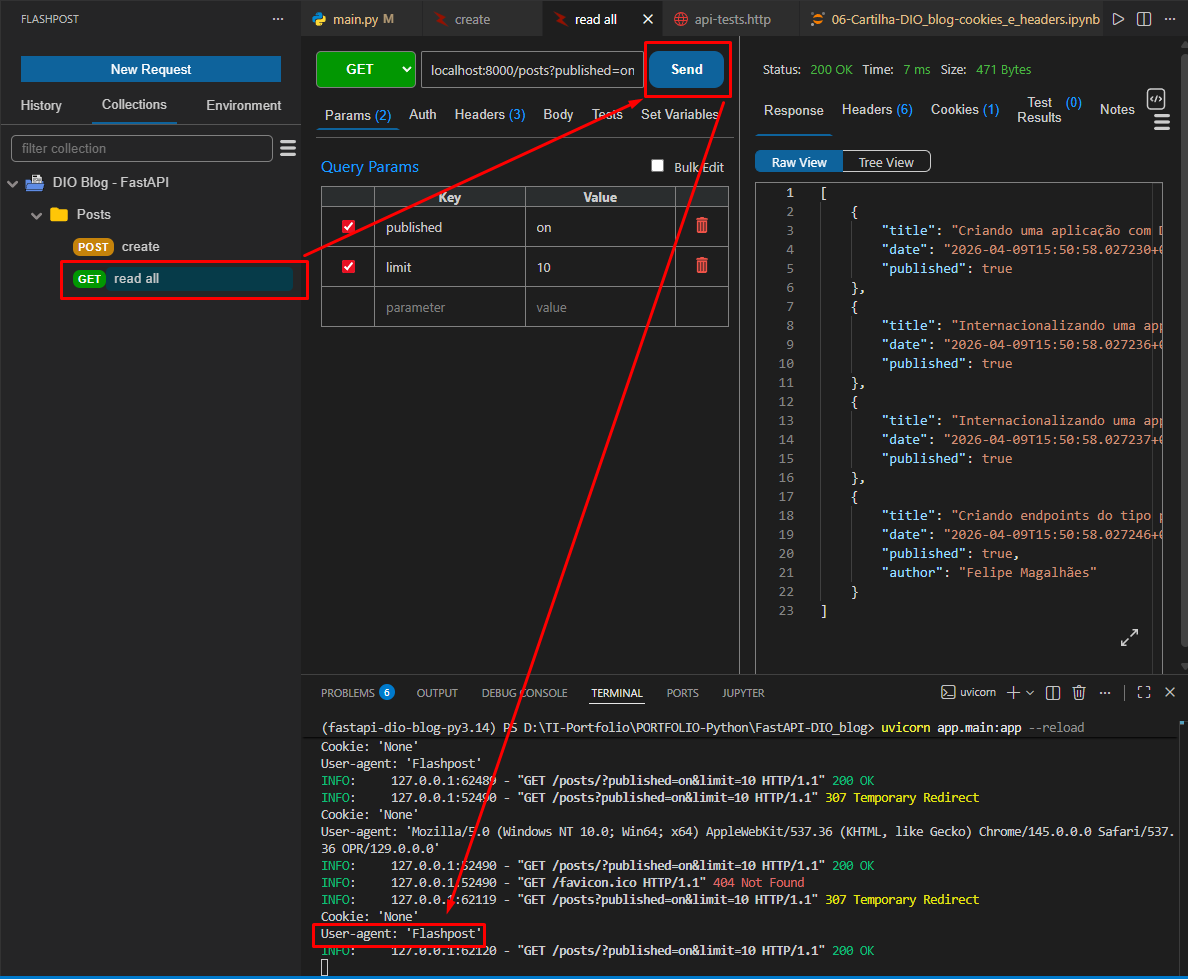